# **MATH-5364 Checkpoint 7 - Final Project**

Authored by: Troyce Mays

Professor/Supervisor: Dr. Scott Cook

Due: 5/2/2025 @ 11:59PM

*Note: Direct indications to references are denoted by an exponential character at the end of sentences.*

---

# ***Predicting Los Angeles Crime Severity Using Machine Learning Models***

## Introduction

In criminal justice, a large subset of research is dedicated to predictive policing. In general, predictive policing is the practice of developing algorithms in order to predict and prevent future crimes based on varying factors. These general factors in predictive policing include details such as locations, past crime trends, victimization patterns, severity of crimes, and more; which often lead to massive datasets and information that must be processed in increasingly technology driven methods. In analyzing crime reports originating from the Los Angeles Police Department (LAPD), this report hopes to develop a machine learning model in order to predict the severity of crimes based on previous reported crimes. In doing so, the information learned could lead to valuable data that may contribute to a future predictive policing models and allocation of LAPD resources.

The dataset used was found from [Data.gov](https://data.gov/), and then eventually traced to a comma separated values (csv) dataset titled "Crime Data from 2020 to Present" from [data.lacity.org](https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data)$^1$. This dataset was originally obtained the evening of February 7, 2025 between the hours of 5:00PM-8:00PM and when obtained it was listed as last updated on February 5, 2025. The dataset describes crime data for the Los Angeles Police Department (LAPD) ranging from 2020 to 2025 with a little over a million rows of data and 28 variables (columns) for use. The dataset was transcribed from the original data within the LAPD and has warnings on the dataset website about possible innacuracies and missing data as a result of this process. In addition, location data is generalized slightly in order to maintain the privacy of individuals tied to the crime data while also excluding any specific personal identifiers that could violate victim privacy. The dataset implements Universal Crime Report (UCR) reporting methods, which generally indicates crimes through the use of a number scale. The first number in the UCR scale often refers to the severity of a crime, and number that follow help to indicate the specific crime committed$^{2,3}$. LAPD is stated to be adopting the National Incident-Based Reporting System (NIBRIS) and will be adjusting their available dataset in the future, but this change was still not in place as of the evening of May 2, 2025; therefore, it will not affect the dataset originally downloaded.

Of the 28 columns available for use in the dataset, a total of 9 were of major interest. These columns were the sex of the victim, the descent (or race) of the victim, the age of the victim, arrest status of the crime, weapon codes representing what weapon was used in a crime, geographic area codes indicating the 21 community police stations within Los Angeles, the specific date a crime occurred on, the specific military time the crime occurred on, and finally the most serious crime committed of each reported crime instance represented as a code based on UCR reporting methods. The crime codes were treated as ordinal variables, being converted from a 100 to 999 scale down to a distinct 1 to 9 scale. The variables for date of the crime and time the crime occurred were converted to the week of the year and hour the time occurred respectively; these were then used as quantitative variables in conjunction with the victim's age. All other variables used were treated as nominal variables.

## Discussion and Methods

### Data Wrangling and Exploratory Data Analyses

Exploratory Data Analysis (EDA) was performed and the dataset was explored through counts of null values, histogram and distribution plot visualizations, and other general exploratory processes. Through EDA, different ways of grouping variables and general guidelines for data imputation were discovered in order to set up feature and target variables. The specific methods for EDA are illustrated in the code cells below along with discussion about discoveries for each section of code to discuss findings that led into the model building phase. Throughout this section, the specific data wrangling methods conducted are illustrated and specific imputations made are also noted for each variable of interest.

In [ ]:
##############################################################
## Imports needed for Exploratory Data Analysis (EDA)
import pathlib, google, numpy as np, pandas as pd, sklearn as sk, matplotlib.pyplot as plt, seaborn as sns
pd.set_option('display.max_columns', None)
google.colab.drive.mount('/content/drive')
root = pathlib.Path('/content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project')

##############################################################
## Code that loads the dataframe and displays initial general info

lacrime_data = pd.read_csv(root/'Crime_Data_from_2020_to_Present.csv')

##
def replace_spaces_with_underscores_in_column_names(df, columns):
    """Replaces spaces with underscores in the specified column names of a DataFrame.

    Args:
        df: The DataFrame to modify.
        columns: A list of column names to modify.

    Returns:
        The modified DataFrame.
    """
    for col in columns:
        if col in df.columns:  # Check if column exists
            df = df.rename(columns={col: col.replace(' ', '_')})
    return df

# Specify the columns you want to modify
columns_to_modify = ['Vict Sex', 'Vict Descent',]

# Apply the function to your DataFrame
lacrime_data = replace_spaces_with_underscores_in_column_names(lacrime_data, columns_to_modify)
##

# Printing Data Frame
print("________________________________________________\n")
print("The column names for the dataset are as follows:\n\n", lacrime_data.columns,
      "\n________________________________________________\n")
print("The number of rows and columns in the data frame are:\n", lacrime_data.shape,
      "\n________________________________________________\n")
# Illustrating null values
null_check = lacrime_data.isnull().sum() > 0
print("The count of null values currently within the dataset are as follows:\n\n",
      lacrime_data[null_check[null_check == True].index].isnull().sum(),
      "\n________________________________________________\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
________________________________________________

The column names for the dataset are as follows:

 Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict_Sex', 'Vict_Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (1004876, 28) 
________________________________________________

The count of null values currently within the dataset are as follows:

 Mocodes            151597
Vict_Sex           144609
Vict_Descent       144621
Premis Cd              16
Premis Desc 

The target variable for this dataset was the Crime Codes, which are UCR based indicators on the type and severity of the crime. In the original dataset there were four extra columns which represented the crime codes for an individual reported crime in reducing severity - Crm Cd 1, 2, 3, 4 respectively - but were deemed unnecessary due to their lack of data in conjunction with the already existing Crime Code target that listed the main offense for that crime. These aspects can be seen in the below code output, and was the reason 'Crm Cd' columns 1, 2, 3 and 4 were dropped from the dataset.
The visualization of crime codes in addition to the first number in UCR crime code reporting illustrating a general severity of the crime done lead to the eventual decision of using floor division to group the 100-999 values of the column into one through nine for the final target variable. This also helped to illustrate that crimes calssified in the 300's are the most numerous, which includes crimes primarily related to burglary or pickpocketing not categorized as violent crimes$^2$.

The total amount of different crime code descriptions was: 140


,bool,count
Crm Cd 2,True,69131
Crm Cd 3,True,2315
Crm Cd 4,True,64


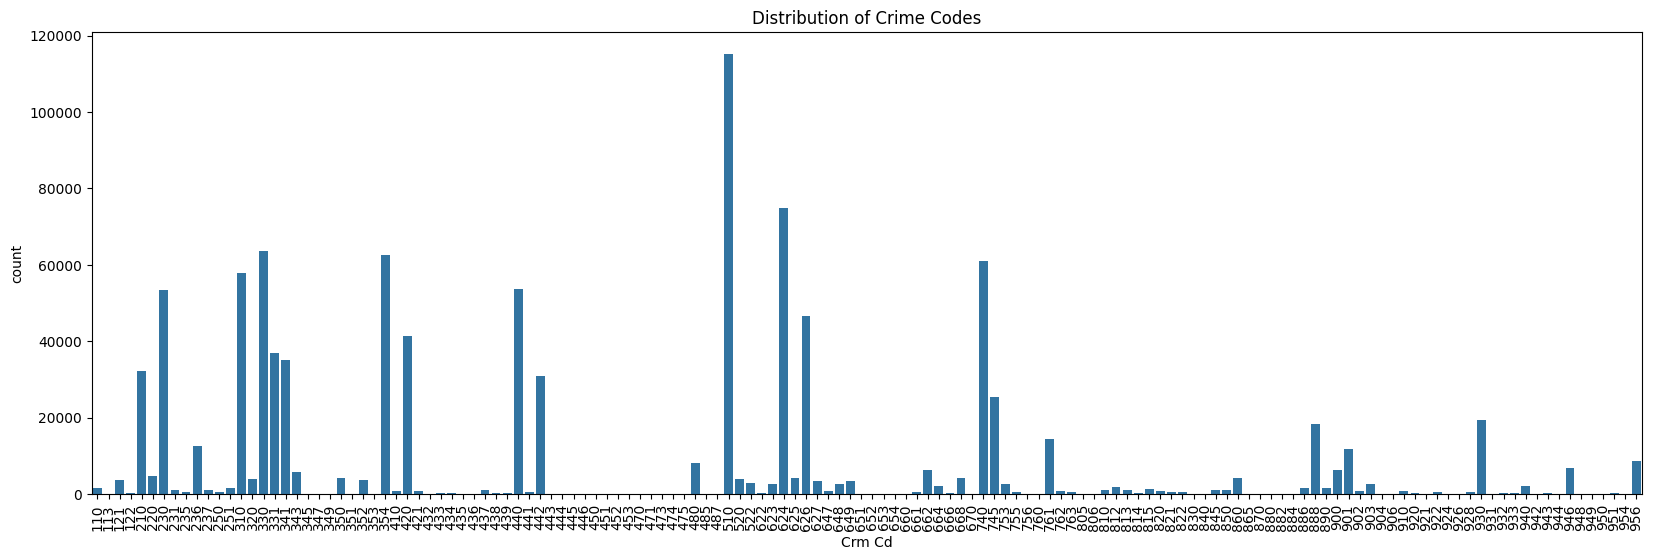

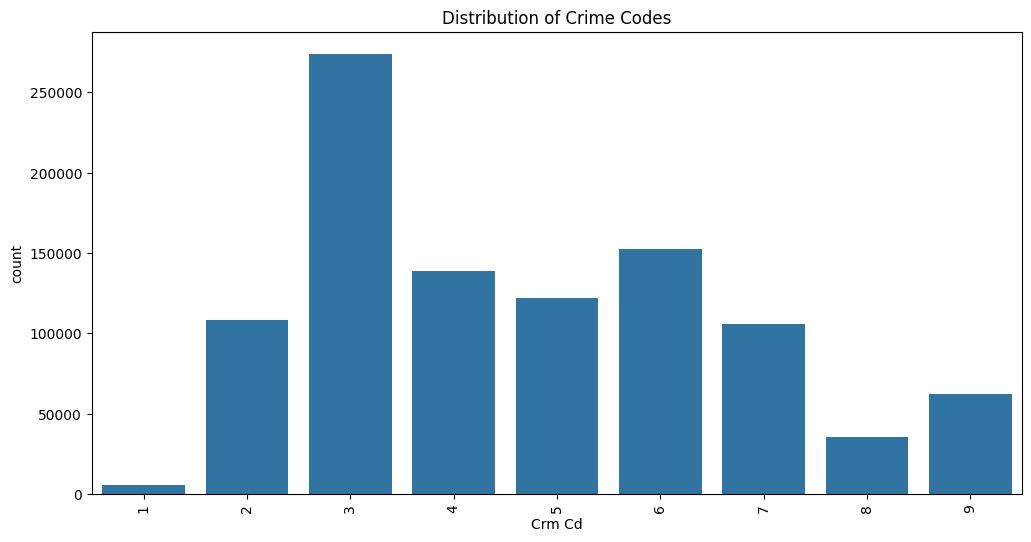

time: 5.46 s (started: 2025-05-03 01:59:36 +00:00)


In [ ]:
# # Identifying Present crime types in dataset (uncomment below line to see all individual descriptions)
# display(lacrime_data["Crm Cd Desc"].unique())

# Finding total amount of different crime descriptions
print('The total amount of different crime code descriptions was:', len(lacrime_data["Crm Cd Desc"].unique()))

# Filtering for columns of data thave have less than 100,000 entries
data_counts100k = lacrime_data.count() < 100000
data_counts100k = data_counts100k[data_counts100k == True].rename('bool') # Giving the bool series a name

# Checking count of entries in True columns
entries_data_counts100k = lacrime_data[data_counts100k[data_counts100k == True].index].count().rename('count') # Giving the count series a name

display(pd.merge(data_counts100k.to_frame(), entries_data_counts100k.to_frame(), left_index=True, right_index=True))

# Visualization of Crime Codes
plt.figure(figsize=(20, 6))
sns.countplot(x='Crm Cd', data=lacrime_data)
plt.title('Distribution of Crime Codes')
plt.xticks(rotation=90)
plt.show()

# Converting Crm Cd to singular digit range
lacrime_data['Crm Cd'] = lacrime_data['Crm Cd']//100

# Visualization of Crime Codes (again)
plt.figure(figsize=(12, 6))
sns.countplot(x='Crm Cd', data=lacrime_data)
plt.title('Distribution of Crime Codes')
plt.xticks(rotation=90)
plt.show()

The next targeted variables were those containing specific victim information. These included the victim age, descent, and recorded sex. In general, these were explored and found to have erroneous values such as negative ages, large amounts of null values (or placeholders for null values in the form of zeroes), and some dashes in place of data where none was to be found. In addition, the victim age column was found to have a singular outlier of 120 for the age, which became a dropped row. The imputations illustrated in the below code would be implemented after the train-test-split of the modeling and holdout sets in the model building section of this report. The specific imputations implemented were the median for the continuous variable victim age due to the large variety of ages present, and then the mode for the nominal variables of victim sex and descent.

[ -4  -3  -2  -1   0   2   3   4   5   6   7   8   9  10  11  12  13  14
  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32
  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68
  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86
  87  88  89  90  91  92  93  94  95  96  97  98  99 120]
['-' 'F' 'H' 'M' 'X' nan]
['-' 'A' 'B' 'C' 'D' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'O' 'P' 'S' 'U' 'V' 'W'
 'X' 'Z' nan]
Amount of age=0:            269152
Amount of negative ages:    135
Amount of H Sex:            114
Amount of '-' Sex:          1
Amount of '-' Descent:      2
The median Age being imputed is: 30.0


array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
       87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

The mode Sex being imputed is: M
The mode Descent being imputed is: H


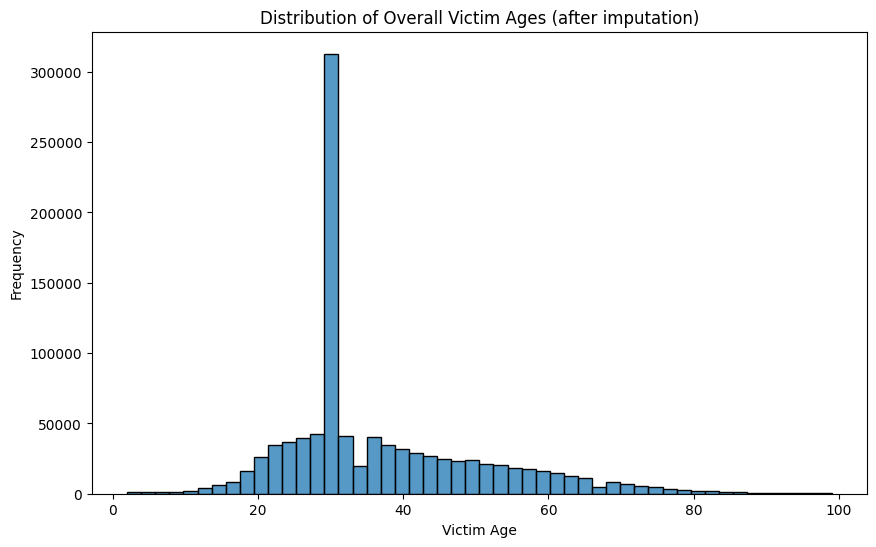

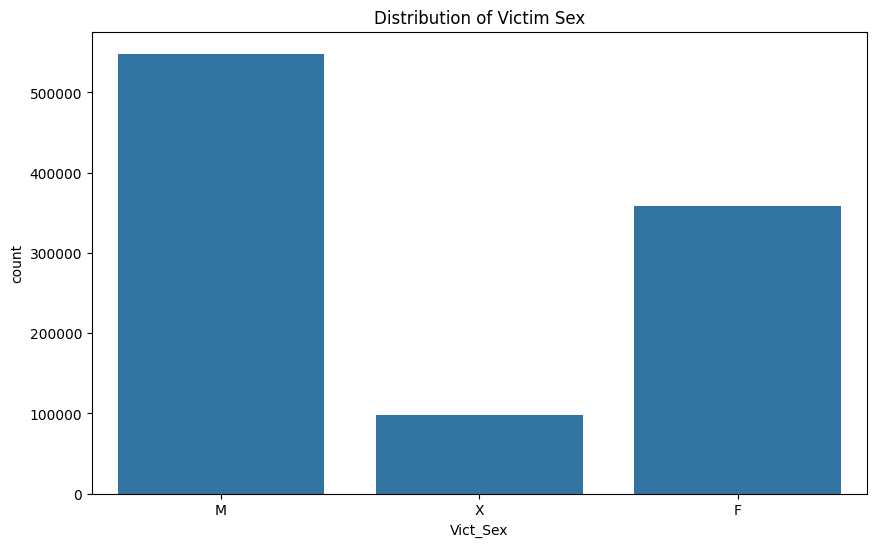

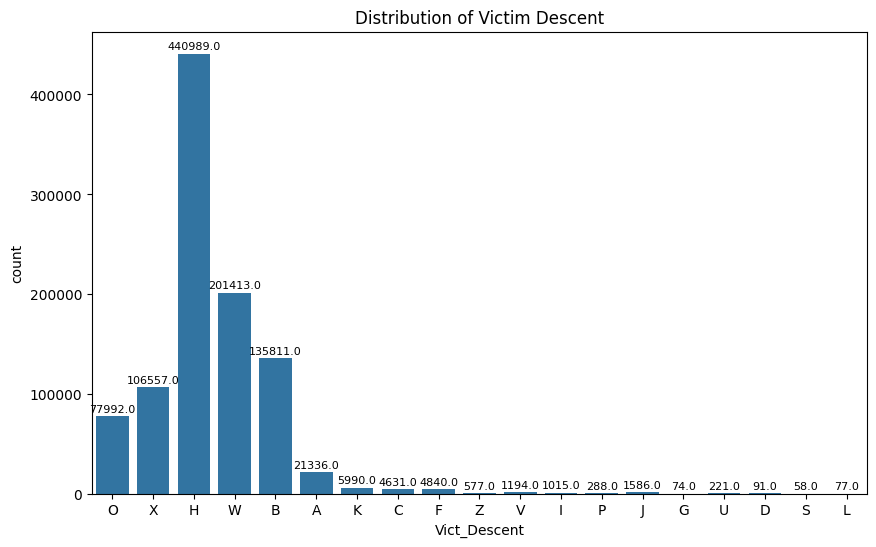

time: 11.2 s (started: 2025-05-03 01:59:42 +00:00)


In [ ]:
##############################################################
### Checking unique values in each victim feature

print(lacrime_data['Vict Age'].sort_values().unique())
print(lacrime_data['Vict_Sex'].sort_values().unique())
print(lacrime_data['Vict_Descent'].sort_values().unique())

##############################################################
### Correcting Victim Information ERRORS (not null)

## Correcting Victim Age
# Taking count of erroneous values
count_zero = (lacrime_data['Vict Age'] == 0).sum()
count_negative = (lacrime_data['Vict Age'] < 0).sum()
# Dropping the age 120, it's definitely an error or extreme outlier
lacrime_data = lacrime_data[lacrime_data['Vict Age'] != 120]
print("Amount of age=0:           ", count_zero)
print("Amount of negative ages:   ", count_negative)
# Note the large amount of zero ages, maybe consider these as null values? ####
# Removing negative ages
lacrime_data = lacrime_data[lacrime_data['Vict Age'] >= 0]
lacrime_data['Vict Age'].sort_values().unique()

## Correcting Victim Sex
# Checking amount of H and - values
count_H = (lacrime_data['Vict_Sex'] == 'H').sum()
count_dash = (lacrime_data['Vict_Sex'] == '-').sum()
print("Amount of H Sex:           ", count_H)
print("Amount of '-' Sex:         ", count_dash)
# lacrime_data['Vict_Sex'].value_counts()
# Changing all H's to X's because the true value is unknown
lacrime_data.loc[lacrime_data['Vict_Sex'] == 'H', 'Vict_Sex'] = 'X'
lacrime_data.loc[lacrime_data['Vict_Sex'] == '-', 'Vict_Sex'] = 'X'
lacrime_data['Vict_Sex'].sort_values().unique()

## Correcting Victim Descent
# Checking amount of "-" values
count_dash2 = (lacrime_data['Vict_Descent'] == '-').sum()
print("Amount of '-' Descent:     ", count_dash2)
lacrime_data.loc[lacrime_data['Vict_Descent'] == '-', 'Vict_Descent'] = 'X'
lacrime_data['Vict_Descent'].sort_values().unique();

## Imputing Data for Victim Information
MedianVicAge = lacrime_data['Vict Age'].median()
print("The median Age being imputed is:", MedianVicAge)
lacrime_data.loc[lacrime_data['Vict Age'] == 0, 'Vict Age'] = MedianVicAge
display(lacrime_data['Vict Age'].sort_values().unique())

# Impute the Mode for Victim Sex and Victim Descent
print("The mode Sex being imputed is:", lacrime_data['Vict_Sex'].mode()[0])
print("The mode Descent being imputed is:", lacrime_data['Vict_Descent'].mode()[0])
for col in ['Vict_Sex', 'Vict_Descent']:
    lacrime_data[col] = lacrime_data[col].fillna(lacrime_data[col].mode()[0])

##############################################################
### Displaying visualizations after correcting erroneous values and imputations

## Victim Age
plt.figure(figsize=(10, 6))
sns.histplot(lacrime_data['Vict Age'], bins=50)
plt.title('Distribution of Overall Victim Ages (after imputation)')
plt.xlabel('Victim Age')
plt.ylabel('Frequency')
plt.show()

## Victim Sex
plt.figure(figsize=(10, 6))
sns.countplot(x='Vict_Sex', data=lacrime_data)
plt.title('Distribution of Victim Sex')
plt.show()

## Victim Descent
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Vict_Descent', data=lacrime_data)
plt.title('Distribution of Victim Descent')

# Annotate each bar with its count
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

plt.show()

The next variables set for analysis were the Premise Codes and Status. With the premise codes being the individual codes representing the specific locations the crime took place and status being the arrest outcome of the reported crime. The premise codes were found to be too varying in number and descriptions to be accurately grouped; however, Status was able to be quickly cleaned by just dropping its single null value and then including it in the model. Its general information is included below.

array(['Adult Arrest', 'Invest Cont', 'Adult Other', 'Juv Arrest',
       'Juv Other', 'UNK'], dtype=object)

array(['AA', 'IC', 'AO', 'JA', 'JO', 'CC'], dtype=object)

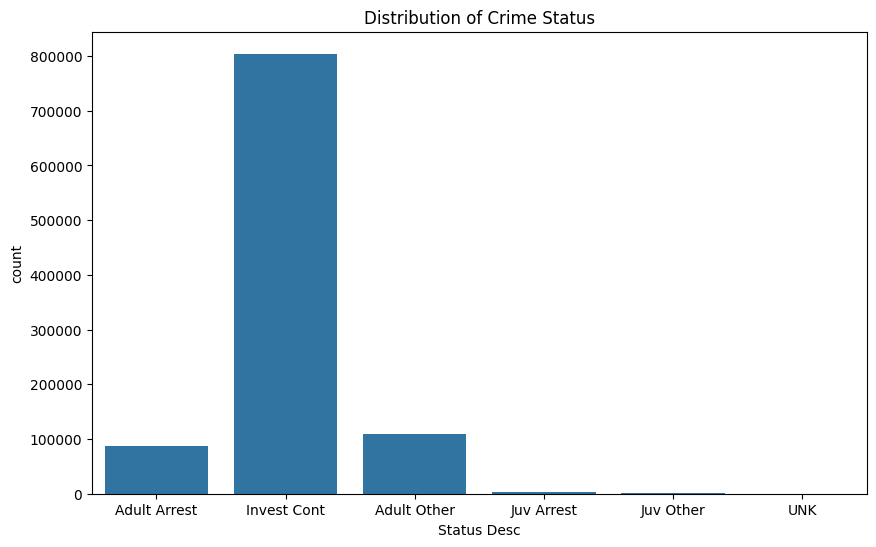

In [ ]:
## Status Columns EDA
# Dislaying unique values
lacrime_data = lacrime_data.dropna(subset=['Status'])
display(lacrime_data['Status Desc'].unique())
display(lacrime_data['Status'].unique())

plt.figure(figsize=(10, 6))
sns.countplot(x='Status Desc', data=lacrime_data)
plt.title('Distribution of Crime Status')
plt.show()

The columns for 'Rpt Dist No' and those relating to the premises the crime occurred on were not used. These columns were too varying in their data and were not able to be reliably grouped for the purpose of the model as is. Future iterations of model building could try to implement the premises information in order to more accurately guess crime severity based on this information.

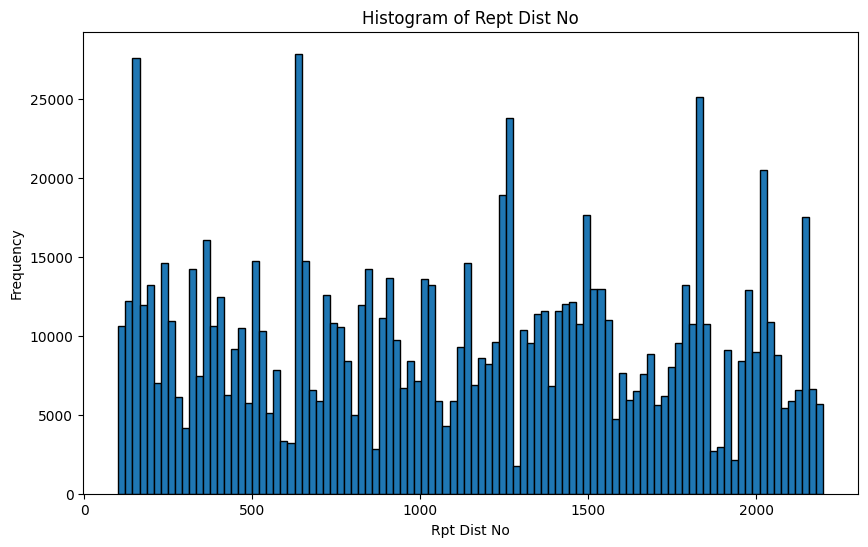

________________________________________________
 The unique values for premise codes are as follows:

 [101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114.
 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126. 127. 128.
 129. 135. 136. 137. 138. 139. 140. 141. 142. 143. 144. 145. 146. 147.
 148. 149. 150. 151. 152. 154. 155. 156. 157. 158. 201. 202. 203. 204.
 205. 206. 207. 208. 209. 210. 211. 212. 213. 214. 215. 216. 217. 218.
 219. 220. 221. 222. 223. 224. 225. 227. 228. 229. 230. 231. 232. 233.
 234. 235. 236. 237. 238. 239. 240. 241. 242. 243. 244. 245. 246. 247.
 248. 249. 250. 251. 252. 253. 254. 255. 256. 301. 302. 303. 304. 305.
 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414.
 415. 416. 417. 418. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510.
 511. 512. 513. 514. 515. 516. 517. 518. 519. 601. 602. 603. 604. 605.
 606. 607. 608. 701. 702. 703. 704. 705. 706. 707. 708. 709. 710. 711.
 712. 713. 714. 715. 716. 717. 718. 719. 720

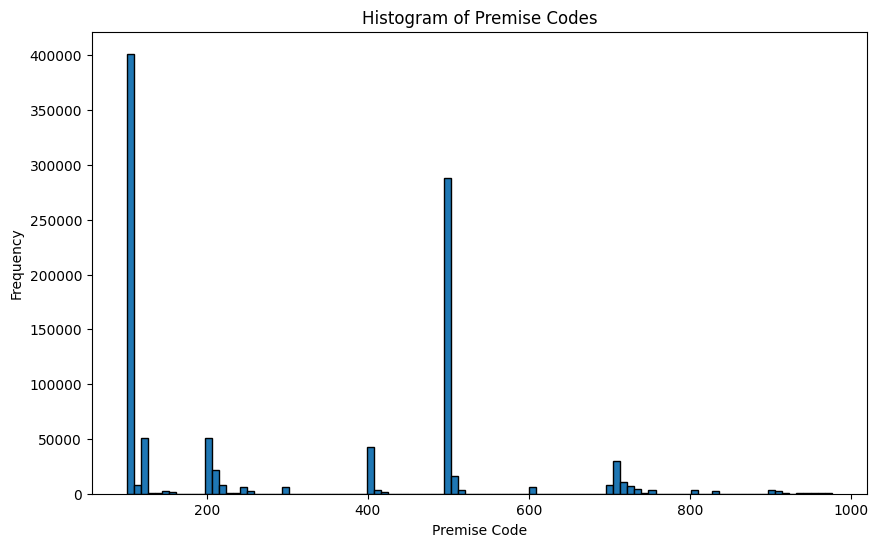

In [ ]:
##############################################################
### Rpt Dist No information (not used in final model)
pd.DataFrame(lacrime_data['Rpt Dist No'].sort_values().unique().transpose())

plt.figure(figsize=(10, 6))
plt.hist(lacrime_data['Rpt Dist No'], bins=100, edgecolor='black')
plt.xlabel('Rpt Dist No')
plt.ylabel('Frequency')
plt.title('Histogram of Rept Dist No')
plt.show()

##############################################################
### Premise Code information (not used in final model)
print("________________________________________________\n",
      "The unique values for premise codes are as follows:\n\n",
      lacrime_data['Premis Cd'].sort_values().unique(),
      "\n________________________________________________\n")

plt.figure(figsize=(10, 6))
plt.hist(lacrime_data['Premis Cd'], bins=100, edgecolor='black')
plt.xlabel('Premise Code')
plt.ylabel('Frequency')
plt.title('Histogram of Premise Codes')
plt.show()

The final columns that were explored were those relating to the weapon used in the crime. It was important to be careful with the implementation of this column so any model built did not learn too much information about the crime and overfit as a result. For this, general grouping would be necessary to generalize the results slightly. After EDA, it was discovered they could be grouped based on type of weapon used, leading to the creation of a new column for use in future models that illustrates this idea. Null values were treated as no weapon being used in the reported crime.

________________________________________________
 The unique values for weapon usage codes are as follows:

 [101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114.
 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 200. 201. 202.
 203. 204. 205. 206. 207. 208. 209. 210. 211. 212. 213. 214. 215. 216.
 217. 218. 219. 220. 221. 223. 300. 301. 302. 303. 304. 305. 306. 307.
 308. 309. 310. 311. 312. 400. 500. 501. 502. 503. 504. 505. 506. 507.
 508. 509. 510. 511. 512. 513. 514. 515. 516.  nan] 
________________________________________________



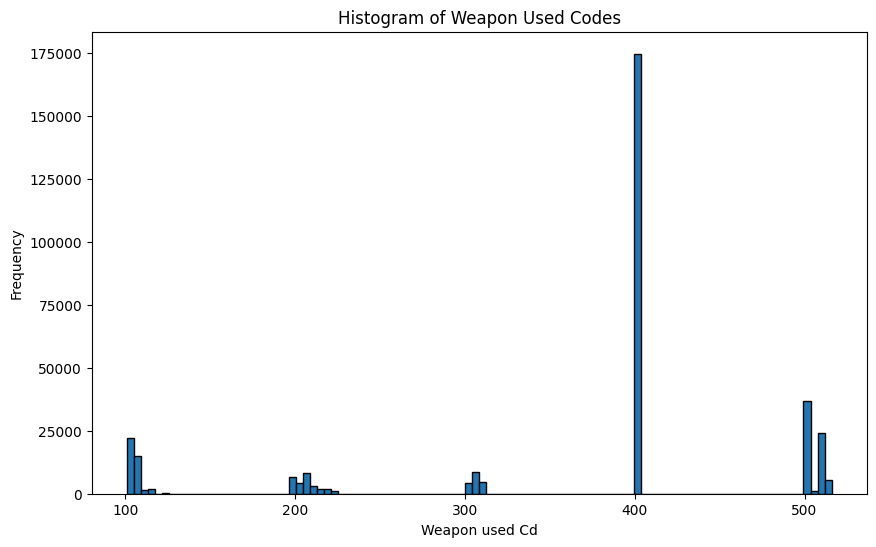

         Weapon Used Cd                                     Weapon Desc
3467              101.0                                        REVOLVER
289610            102.0                                        HAND GUN
350281            103.0                                           RIFLE
221213            104.0                                         SHOTGUN
195472            105.0                         SAWED OFF RIFLE/SHOTGUN
315199            106.0                                 UNKNOWN FIREARM
49873             107.0                                   OTHER FIREARM
450028            108.0                AUTOMATIC WEAPON/SUB-MACHINE GUN
474952            109.0                           SEMI-AUTOMATIC PISTOL
540441            110.0                            SEMI-AUTOMATIC RIFLE
512902            111.0                         STARTER PISTOL/REVOLVER
767980            112.0                                         TOY GUN
748928            113.0                                   SIMULA

In [ ]:
##############################################################
### Weapon Used Code information
print("________________________________________________\n",
      "The unique values for weapon usage codes are as follows:\n\n",
      lacrime_data['Weapon Used Cd'].sort_values().unique(),
      "\n________________________________________________\n")

plt.figure(figsize=(10, 6))
plt.hist(lacrime_data['Weapon Used Cd'], bins=100, edgecolor='black')
plt.xlabel('Weapon used Cd')
plt.ylabel('Frequency')
plt.title('Histogram of Weapon Used Codes')
plt.show()

## A large count of "400" can be seen in generated figure. A row can be printed to show what 400 refers to.
# Figuring out why 400 is such a large bar in the histogram
pd.set_option("display.max_columns", None)
lacrime_data[lacrime_data['Weapon Used Cd'] == 400].head(1)
# Note it is referring to the body being the weapon


## Generating a dataframe specifically for the weapon infromation columns
weapons_info = lacrime_data[['Weapon Used Cd', 'Weapon Desc']]
weapons_info = weapons_info.sort_values(by='Weapon Used Cd').drop_duplicates()

# Doing a temporary set on max columns applicable to only this cell (Achieved with assistance from GoogleAI)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print(weapons_info)

##############################################################
### Grouping and displaying new Weapon Codes into new column

## Code to group the Weapon Use Cd
lacrime_data['Weapon Cd Groups'] = lacrime_data['Weapon Used Cd']//100
lacrime_data['Weapon Cd Groups'] = lacrime_data['Weapon Cd Groups'].replace({
    1: 'Firearm',
    2: 'Cutting_Instrument',
    3: 'Blunt_Force_Weapon',
    4: 'Strong-Arm',
    5: 'Other_Weapons-Threats',
    np.nan: 'No_Recorded_Weapon',
})

print("________________________________________________\n",
      "The unique values for the new column - Weapon Cd Group - are as follows:\n\n",
      lacrime_data['Weapon Cd Groups'].sort_values().unique(),
      "\n________________________________________________\n")

### Model Building

In [ ]:
# Note runtime will need to be reset after running this pip install statement
%pip install dill ipython-autotime flaml[automl] numpy==1.24.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
blosc2 3.3.1 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jaxlib 0

In [ ]:
##############################################################
## Imports needed to conduct model building
%load_ext autotime

import pathlib, google, logging, dill, dataclasses, numpy as np, pandas as pd, sklearn as sk, matplotlib.pyplot as plt, seaborn as sns
from copy import deepcopy as copy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.inspection import permutation_importance
from flaml import AutoML
from sklearn.multiclass import OneVsRestClassifier # Importing OneVsRestClassifier
from sklearn.metrics import auc, roc_curve

pd.set_option('display.max_columns', None)
logging.getLogger("flaml.tune.searcher.blendsearch").setLevel(logging.WARNING)
google.colab.drive.mount('/content/drive')
root = pathlib.Path('/content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project')
seed = 42

##############################################################
## Dr. Cook's display method used within his developed class
def disp(X, max_rows=3, precision=None, **props):
    """convenient display method"""
    props = {
        'text-align': 'center',
        'vertical-align': 'top',
        'border': '1px solid white',
        'width': 'auto',
        } | props
    fmt = {'precision': precision, 'hyperlinks': 'html'}
    try:
        display(
            pd.DataFrame(X)
            .head(max_rows)
            .style
            .format(**fmt)
            .format_index(**fmt, axis=0)
            .format_index(**fmt, axis=1)
            .highlight_null()
            .set_table_styles([{'selector':k, 'props':[*props.items()]} for k in ['th','td']])
        )
    except:
        print(X)

## Dr. Cook's file path system for storing outputs using dill/pathlib
def rm(path, root=False):
    path = pathlib.Path(path)
    if path.is_file():
        path.unlink()
    elif path.is_dir():
        if root:
            shutil.rmtree(path)
        else:
            for p in path.iterdir():
                rm(p, True)

def mkdir(path):
    path = pathlib.Path(path)
    folder = path if path.suffix == '' else path.parent
    folder.mkdir(parents=True, exist_ok=True)
    return path

def reset(path):
    rm(path)
    return mkdir(path)

def dump(path, obj, **kwargs):
    path = reset(path)
    print(f'dump to {path}')
    if not isinstance(obj, pd.DataFrame):
        with open(path, 'wb') as f:
            return dill.dump(obj, f, **kwargs)
    elif path.suffix == '.parquet':
        obj.to_parquet(path, **kwargs)
    elif path.suffix == '.csv':
        obj.to_csv(path, **kwargs)
    else:
        raise Exception('path suffix must be .parquet or .csv if obj is a DataFrame')

def load(path, **kwargs):
    path = pathlib.Path(path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path, **kwargs)
    elif path.suffix == '.csv':
        return pd.read_csv(path, **kwargs)
    else:
        with open(path, 'rb') as f:
            return dill.load(f, **kwargs)

##############################################################
## Code that loads the dataframe and displays initial general info

lacrime_data = pd.read_csv(root/'Crime_Data_from_2020_to_Present.csv')

def replace_spaces_with_underscores_in_column_names(df, columns):
    """Replaces spaces with underscores in the specified column names of a DataFrame.

    Args:
        df: The DataFrame to modify.
        columns: A list of column names to modify.

    Returns:
        The modified DataFrame.
    """
    for col in columns:
        if col in df.columns:  # Check if column exists
            df = df.rename(columns={col: col.replace(' ', '_')})
    return df

# Specify the columns you want to modify
columns_to_modify = ['Vict Sex', 'Vict Descent',]

# Apply the function to your DataFrame
lacrime_data = replace_spaces_with_underscores_in_column_names(lacrime_data, columns_to_modify)

# Display the modified DataFrame (optional)
# disp(df)

# Printing Data Frame
print("________________________________________________\n")
print("The column names for the dataset are as follows:\n\n", lacrime_data.columns,
      "\n________________________________________________\n")
print("The number of rows and columns in the data frame are:\n", lacrime_data.shape,
      "\n________________________________________________\n")
# Illustrating null values
null_check = lacrime_data.isnull().sum() > 0
print("The count of null values currently within the dataset are as follows:\n\n",
      lacrime_data[null_check[null_check == True].index].isnull().sum(),
      "\n________________________________________________\n")

##############################################################
### Pre-split Preprocessing that can be done to the original dataset

def pre_wrangling(df):

  # Dropping general null values where applicable
  df = df.dropna(subset=["Status", "Premis Cd"])

  # Correcting/Filtering erroneous values in Vict Age, Sex, and Descent
  df = df[df['Vict Age'] >= 0]
  df = df[df['Vict Age'] != 120]
  df.loc[df['Vict_Sex'] == 'H', 'Vict_Sex'] = 'X'
  df.loc[df['Vict_Sex'] == '-', 'Vict_Sex'] = 'X'
  df.loc[df['Vict_Descent'] == '-', 'Vict_Descent'] = 'X'

  # Dropping unnecessary columns
  df = df.drop(columns=[
      "Crm Cd 1",
      "Crm Cd 2",
      "Crm Cd 3",
      "Crm Cd 4",
      ])

  # Making a "WeekOfTheYear" column
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
  df['WeekOfYear'] = df['DATE OCC'].dt.isocalendar().week

  # Converting Military Time w/ minutes to 0-23 range
  df['TIME OCC'] = df['TIME OCC']//100

  # Converting Crm Cd to singular digit range
  df['Crm Cd'] = df['Crm Cd']//100

  # Creating a Weapon Groups column
  df['Weapon Cd Groups'] = df['Weapon Used Cd']//100
  df['Weapon Cd Groups'] = df['Weapon Cd Groups'].replace({
      1: 'Firearm',
      2: 'Cutting_Instrument',
      3: 'Blunt_Force_Weapon',
      4: 'Strong-Arm',
      5: 'Other_Weapons-Threats',
      np.nan: 'No_Recorded_Weapon',
  })

  # Returning the Function
  return df

## Returning the dataframe after using "pre_wrangling"
df = lacrime_data = pre_wrangling(lacrime_data)

# ## Creating a smaller sample for faster model building, below lines should be disabled once a "best" model is found
# df = df.sample(frac=0.60, random_state=seed)

# print("________________________________________________\n")
# print("The column names for the partial dataset are as follows:\n\n", df.columns,
#       "\n________________________________________________\n")
# print("The number of rows and columns in the partial data frame are:\n", df.shape,
#       "\n________________________________________________\n")
# # Illustrating null values
# null_check = df.isnull().sum() > 0
# print("The count of null values currently within the partial dataset are as follows:\n\n",
#       df[null_check[null_check == True].index].isnull().sum(),
#       "\n________________________________________________\n")

Mounted at /content/drive
________________________________________________

The column names for the dataset are as follows:

 Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict_Sex', 'Vict_Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (1004876, 28) 
________________________________________________

The count of null values currently within the dataset are as follows:

 Mocodes            151597
Vict_Sex           144609
Vict_Descent       144621
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677674
Weapon Desc        677674
Status                  1
Crm Cd 1   

<ipython-input-1-e26894e02a3c>:161: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


time: 55.4 s (started: 2025-05-03 00:04:39 +00:00)


In [ ]:
###  Creating a class for model building
@dataclasses.dataclass
class lacrime():
    wrangler: any
    learner: any
    param_grid: any
    scorer: any
    target: str = 'Crm Cd'
    n_splits: int = 3
    refit_time: int = 60
    n_repeats: int = 10
    path: str = None

    def __post_init__(self):
      self.now = pd.Timestamp.now()
      self.path = mkdir(self.path if self.path is not None else root/f'models/{self.now}.pkl')

      #make modeling & holdout sets
      X = copy(df)
      y = X.pop(self.target)
      self.X_modeling, self.X_holdout, self.y_modeling, self.y_holdout = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
      #make estimator & grid
      self.learner.__sklearn_tags__ = getattr(sk.base, self.learner._estimator_type.capitalize()+'Mixin')().__sklearn_tags__  # stupid hack to correct FLAML/sklearn bug in ConfusionMatrixDisplay
      self.estimator = Pipeline((('wrangle', self.wrangler), ('learn', self.learner)))
      self.grid = GridSearchCV(self.estimator, self.param_grid, cv=self.n_splits, scoring=self.scorer, refit=False)

    def train(self):
      # Runs GridSearchCV
      self.grid.fit(self.X_modeling, self.y_modeling)

      # For FLAML, retrains best est w/ larger time budget and cv
      kwargs = {
          'time_budget': self.refit_time,
          'retrain_full': True,
          'eval_method': 'cv',
          'n_splits': self.n_splits,
      }
      kwargs = {f'learn__{k}':v for k,v in kwargs.items() if k in self.learner.get_params()}
      self.estimator = self.estimator.set_params(**self.grid.best_params_).fit(self.X_modeling, self.y_modeling, **kwargs)

      # Code to run prediction on modeling and holdout sets
      self.pred_modeling = self.estimator.predict(self.X_modeling)
      self.pred_holdout  = self.estimator.predict(self.X_holdout)

    def evaluate(self, subpopulations=[]):
      # Obtains the name of the best algorithm
      self.algorithm = getattr(self.estimator['learn'], 'best_estimator', str(self.estimator['learn']).split('(')[0])
      disp(self.algorithm)

      # Prints all cv results from GridSearchCV
      self.grid.cv_df = pd.DataFrame(self.grid.cv_results_['params']).assign(cv_score=self.grid.cv_results_['mean_test_score']).sort_values('cv_score', ascending=False).rename_axis(index='grid_id')
      disp(self.grid.cv_df, None)

      # Displaying best the estimator's scores
      self.scores = {'cv':self.grid.best_score_, 'holdout':self.scorer(self.estimator, self.X_holdout, self.y_holdout)}
      disp(self.scores)

      for qry in subpopulations:
          mask = self.X_holdout.eval(qry)
          # mask = self.X_holdout.eval(qry.replace(" ", "_"))
          self.scores[qry] = self.scorer(self.estimator, self.X_holdout[mask], self.y_holdout[mask])

      for k, v in self.scores.items():
          print(f'{k}: {v:.3f}')

      # Creating report for the model
      self.classification_report = classification_report(self.y_holdout, self.pred_holdout)
      disp(self.classification_report)
      ConfusionMatrixDisplay.from_estimator(self.estimator, self.X_holdout, self.y_holdout)
      # RocCurveDisplay.from_estimator(self.estimator, self.X_holdout, self.y_holdout)

      # ----------------------------------------------------------------------------
      # GoogleAI prompt: how can i implement a one vs many multiclass roc curve instead of the binary one in the code currently
      # Implementing one-vs-many ROC curve
      # ----------------------------------------------------------------------------
      # Creating a OneVsRestClassifier with the base estimator
      ovr_classifier = OneVsRestClassifier(self.estimator)
      # Fitting the classifier to the modeling data
      ovr_classifier.fit(self.X_modeling, self.y_modeling)
      # Getting predicted probabilities for the holdout set
      y_score = ovr_classifier.predict_proba(self.X_holdout)

      # Creating figure and axes for the ROC curve
      fig, ax = plt.subplots(figsize=(10, 8))

      # Plotting ROC curve for each class
      n_classes = len(ovr_classifier.classes_)
      for i in range(n_classes):
        fpr, tpr, _ = roc_curve(self.y_holdout == ovr_classifier.classes_[i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'Class {ovr_classifier.classes_[i]} (AUC = {roc_auc:.2f})')

      # Setting plot properties
      ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
      ax.set_xlim([0.0, 1.0])
      ax.set_ylim([0.0, 1.05])
      ax.set_xlabel('False Positive Rate')
      ax.set_ylabel('True Positive Rate')
      ax.set_title('Receiver Operating Characteristic (One-vs-Many)')
      ax.legend(loc="lower right")
      plt.show()
      # ----------------------------------------------------------------------------


      ## Display feature importance (permutation) in a swarmplot
      imp = permutation_importance(self.estimator, self.X_modeling, self.y_modeling, n_repeats=self.n_repeats, random_state=seed)
      self.importances = pd.DataFrame(imp.importances.T, columns=self.X_modeling.columns)
      mu = self.importances.mean().sort_values(ascending=False)
      # Swarm or Histplots can be used here, final model uses stripplot
      # sns.swarmplot(self.importances[mu[mu>0].index], orient='h')
      sns.stripplot(self.importances[mu[mu>0].index], orient='h')
      plt.xlabel('permutation importance')
      plt.show()

    def run(self):
      print('\n#########################################################################################################################################\n')
      self.train()
      self.evaluate()
      dump(self.path, self)

### Creating a list to contain model iterations
models = []

time: 4.34 ms (started: 2025-05-03 00:05:34 +00:00)


#### Replicating the Initial Model

The below code uses the developed class to recreate the initial model at a much slower speed (about 1h 45min using the full dataset). The original model's F1 Macro Score was: `0.2628` and was trained using:

Vict Age, WeekOfYear, TIME OCC, Vict_Sex, Vict_Descent


#########################################################################################################################################

RandomForestClassifier


,learn__max_depth,learn__n_estimators,cv_score
grid_id,,,
2,15,50,0.259972
3,15,100,0.259762
1,12,100,0.252545
0,12,50,0.252324


{'cv': 0.25997173089480147, 'holdout': 0.2593120368574774}
              precision    recall  f1-score   support

           1       0.20      0.00      0.00       667
           2       0.30      0.17      0.22     13001
           3       0.38      0.77      0.51     32867
           4       0.32      0.19      0.24     16632
           5       0.77      0.96      0.86     14658
           6       0.30      0.25      0.27     18326
           7       0.25      0.01      0.03     12689
           8       0.41      0.14      0.21      4261
           9       0.11      0.00      0.00      7466

    accuracy                           0.42    120567
   macro avg       0.34      0.28      0.26    120567
weighted avg       0.37      0.42      0.35    120567



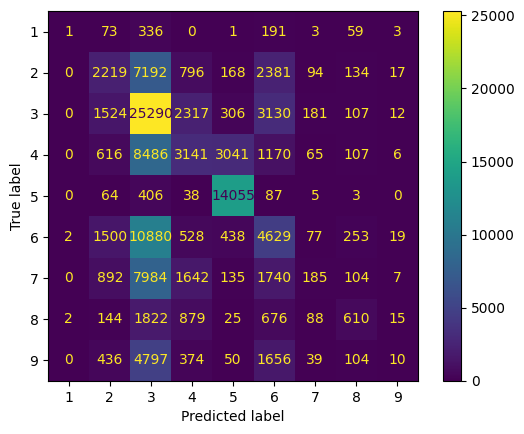

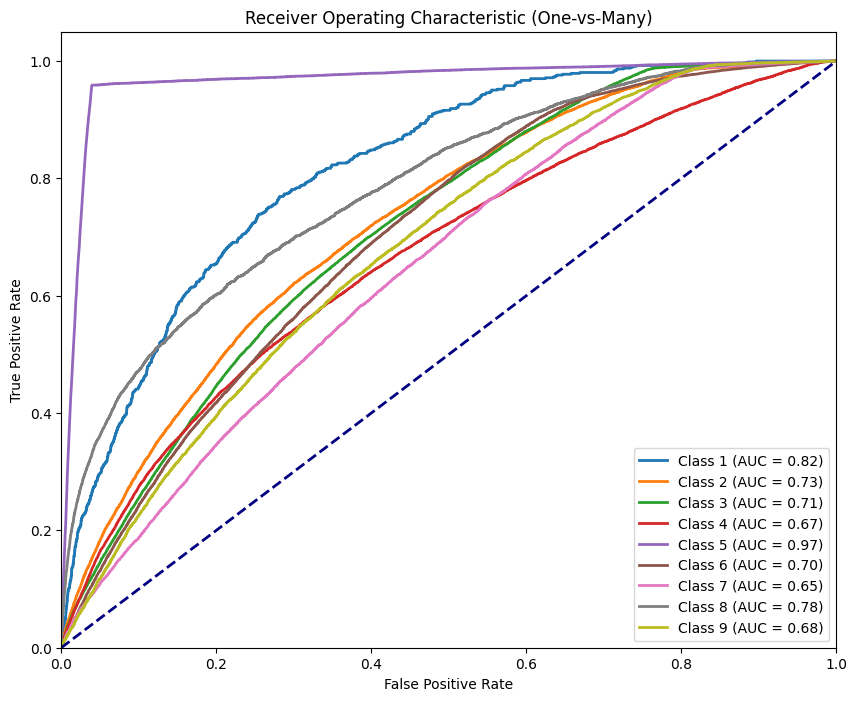

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


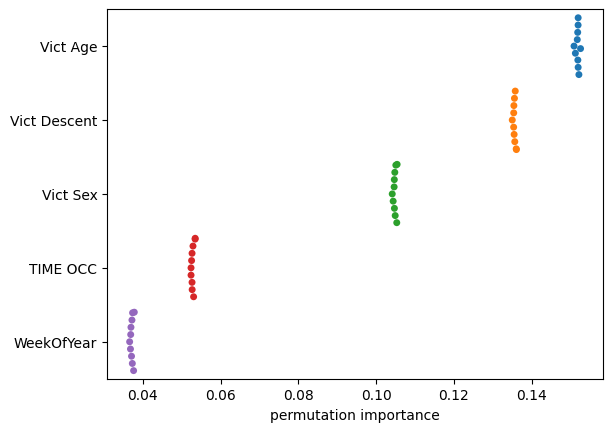

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-24 19:43:18.015333.pkl
time: 41min 58s (started: 2025-04-24 19:43:18 +00:00)


In [ ]:
wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            # ('scale', StandardScaler()),
            # ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            # 'Status',
            # 'Weapon Cd Groups',
            # 'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    'learn__n_estimators': [50, 100],
    'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    RandomForestClassifier(random_state=seed),
    # AutoML(time_budget=20, eval_method='holdout', retrain_full=False,
    #     task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'),) #refit_time=60)
    obj.run()
    models.append(obj)

The replicate of the initial model had a change made to its imputation method for the victim age from previous iterations in order to prevent a data leak. Overall, the performance of the model did not improve; however, the new ROC curve did illustrate that the information on the victims had a much larger permutation importance on the model than the time data. This iteration of the model also ran much slower, finishing at about 1 hour and 45 minutes, which was mostly due to the inclusion of much higher computational efforts needed for the ROC curve and permutation importance scores.



---



#### Replicating the Second Model
 The below code recreates the initial model using FLAML at a slower speed (about 1h 53min using the full dataset). The second model's original F1 Macro Score was: `0.2708` and was trained using the same features as the initial model:

Vict Age, WeekOfYear, TIME OCC, Vict_Sex, Vict_Descent

This new version implemented with the class includes new time adjustments that the original version did not. This includes the original "time_budget" method, which now tells FLAML to find the best model (ex. Random Forests, HistGradientBoosting, LightGBM, etc.). Then a "refit_time" variable that overwrites the time budget after a model has been found, which allows FLAML time to tune its hyperparamaters.


#########################################################################################################################################

lgbm


,cv_score
grid_id,
0,0.265881


{'cv': 0.26588145778311306, 'holdout': 0.2642060222779922}
              precision    recall  f1-score   support

           1       0.67      0.00      0.01       667
           2       0.30      0.18      0.22     13001
           3       0.38      0.76      0.51     32867
           4       0.33      0.18      0.24     16632
           5       0.77      0.96      0.86     14658
           6       0.30      0.27      0.28     18326
           7       0.30      0.02      0.03     12689
           8       0.42      0.16      0.23      4261
           9       0.00      0.00      0.00      7466

    accuracy                           0.42    120567
   macro avg       0.38      0.28      0.26    120567
weighted avg       0.37      0.42      0.35    120567



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


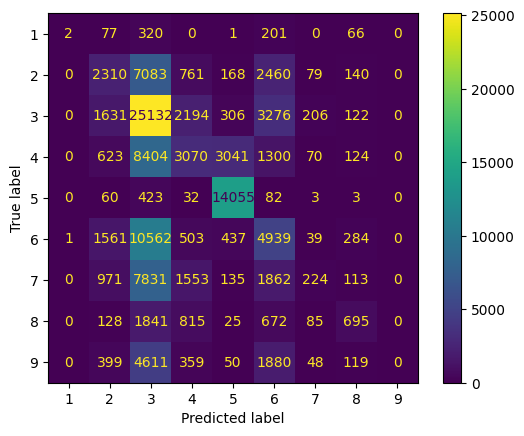

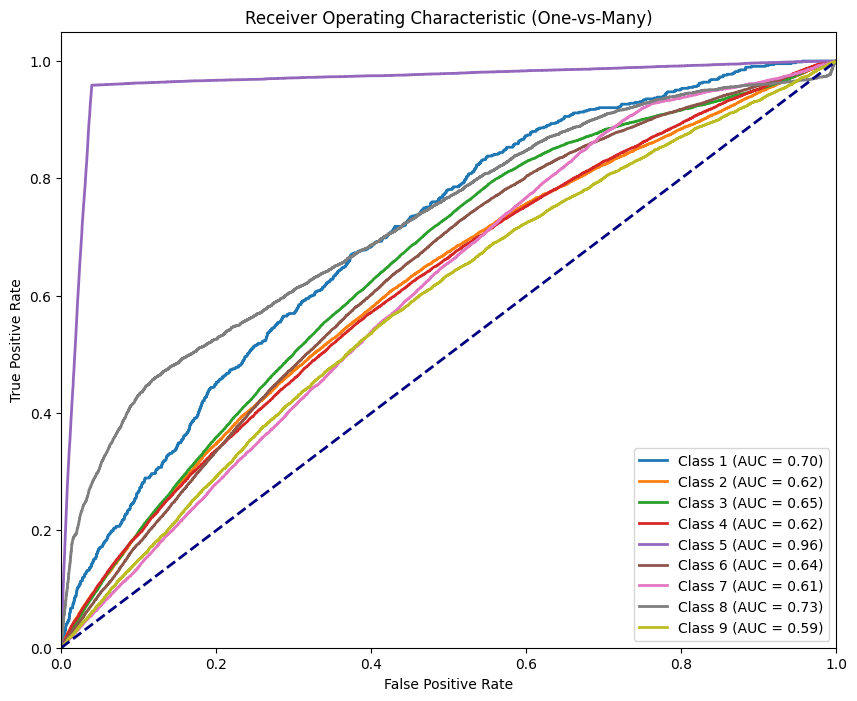

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


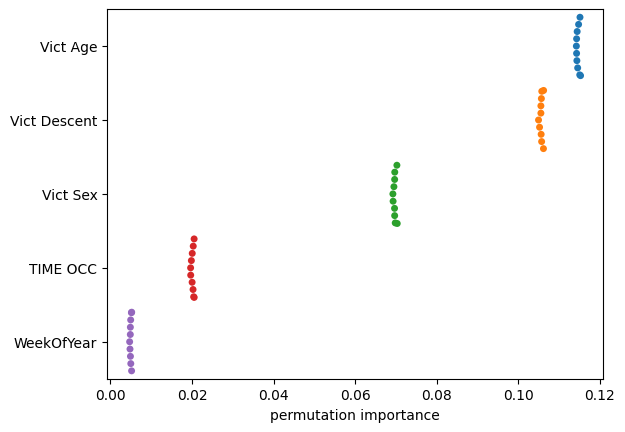

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-24 23:23:31.150965.pkl
time: 1h 26min 35s (started: 2025-04-24 23:23:31 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            # ('scale', StandardScaler()),
            # ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            # 'Status',
            # 'Weapon Cd Groups',
            # 'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.run()
    models.append(obj)

#### Replicating the Third Model
 The below code recreates the third model, implementing FLAML at a slower speed (estimated about 2h using the full dataset). The third model's original F1 Macro Score was: `0.3243` and was trained using some additional features in comparison to the initial model. The following variables all had direct connections to victims themselves and this was the reasoning behind adding them to the model:

'WeekOfYear',
    'TIME OCC',
    'AREA',
    'Status',
    'Vict Age',
    'Vict_Sex',
    'Vict_Descent'

To recreate initial errors from the model, Area was not one-hot encoded although it should have been given it is not a continuous variable but simply a number indicating a district in which a police station is located. In this instance of the model this original error will also be recreated.


#########################################################################################################################################

lgbm


,cv_score
grid_id,
0,0.305093


{'cv': 0.3050927994445396, 'holdout': 0.3079836184540137}
              precision    recall  f1-score   support

           1       0.06      0.02      0.03       667
           2       0.37      0.27      0.32     13001
           3       0.43      0.84      0.57     32867
           4       0.40      0.18      0.25     16632
           5       0.76      0.96      0.85     14658
           6       0.41      0.37      0.39     18326
           7       0.28      0.03      0.05     12689
           8       0.45      0.21      0.29      4261
           9       0.27      0.02      0.03      7466

    accuracy                           0.47    120567
   macro avg       0.38      0.32      0.31    120567
weighted avg       0.43      0.47      0.40    120567



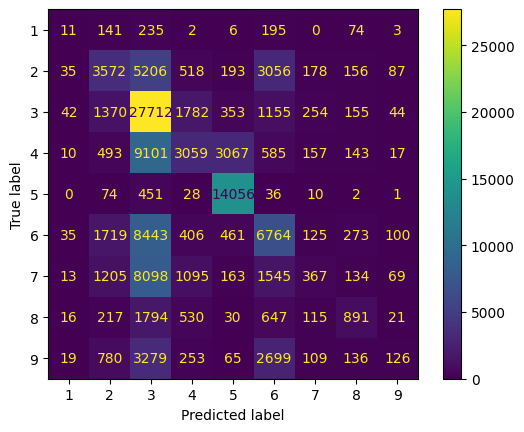

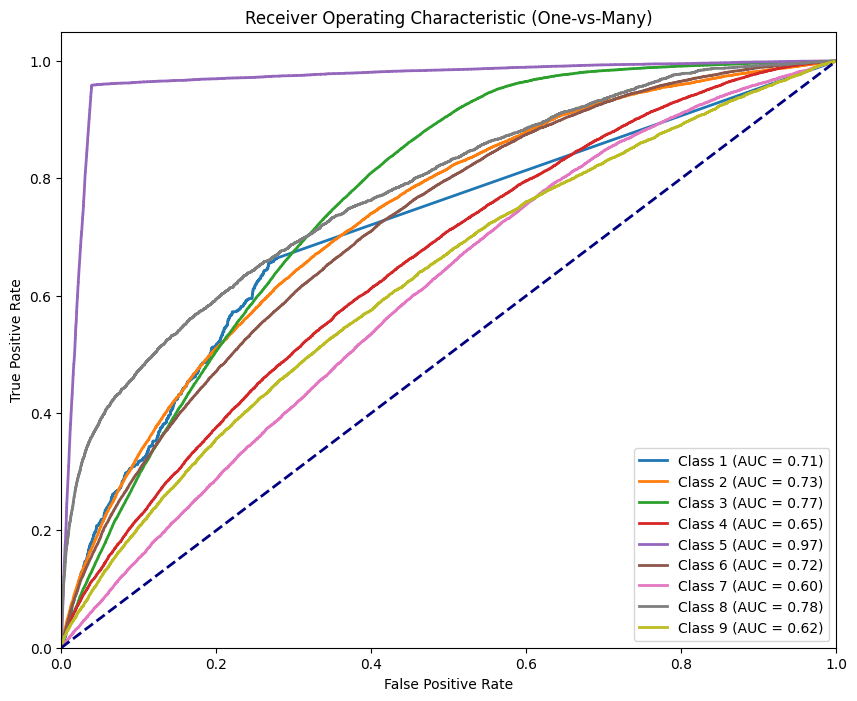

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


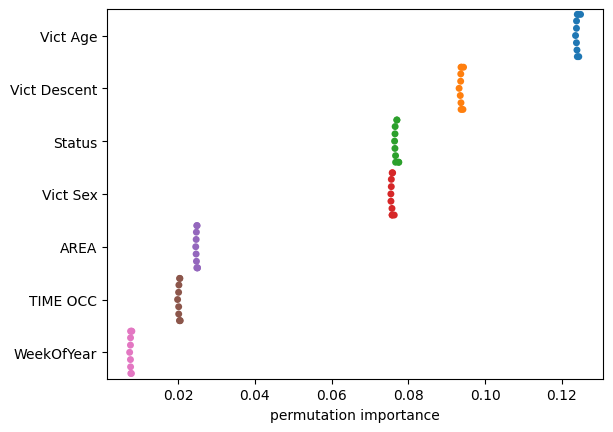

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-25 05:52:40.871347.pkl
time: 3h 56min 12s (started: 2025-04-25 05:52:40 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            # ('scale', StandardScaler()),
            # ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
            'AREA',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            'Status',
            # 'Weapon Cd Groups',
            # 'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.run()
    models.append(obj)

#### Corrected Fourth Model
 The below code recreates the third model, implementing FLAML at a slower speed (estimated about 2h using the full dataset). The fourth model's original F1 Macro Score was: `0.4812` and was trained using two additional features in comparison to the third model iteration, Weapon Use Codes and 'Rept Dist No'. Weapon Use Codes were all grouped into categories based upon the type of weapon used, and the more specific district codes were left as continuous variables. Where this model iteration will differ from its original version is that the 'Rept Dist No' will be left out, as there is no way to reliably group or reliably one-hot encode without sacrificing extreme performance on code execution. The following variables were added to the model:

'WeekOfYear',
    'TIME OCC',
    'AREA',
    'Status',
    'Vict Age',
    'Vict_Sex',
    'Vict_Descent',
    'Weapon Cd Groups'


#########################################################################################################################################

lgbm


,cv_score
grid_id,
0,0.445662


{'cv': 0.4456624561931711, 'holdout': 0.4463243973208676}
              precision    recall  f1-score   support

           1       0.25      0.02      0.04       667
           2       0.65      0.63      0.64     13001
           3       0.55      0.88      0.67     32867
           4       0.44      0.18      0.26     16632
           5       0.79      0.96      0.87     14658
           6       0.70      0.78      0.74     18326
           7       0.38      0.03      0.05     12689
           8       0.54      0.20      0.29      4261
           9       0.45      0.46      0.45      7466

    accuracy                           0.61    120567
   macro avg       0.53      0.46      0.45    120567
weighted avg       0.57      0.61      0.55    120567



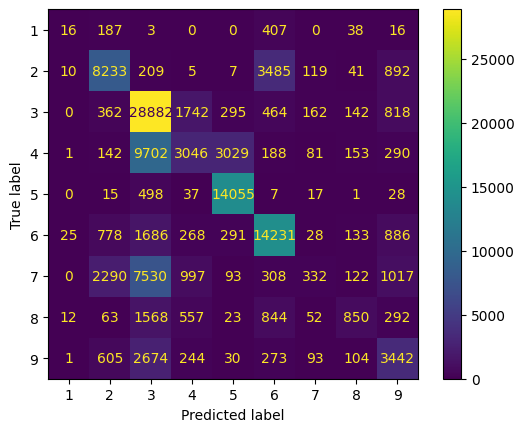

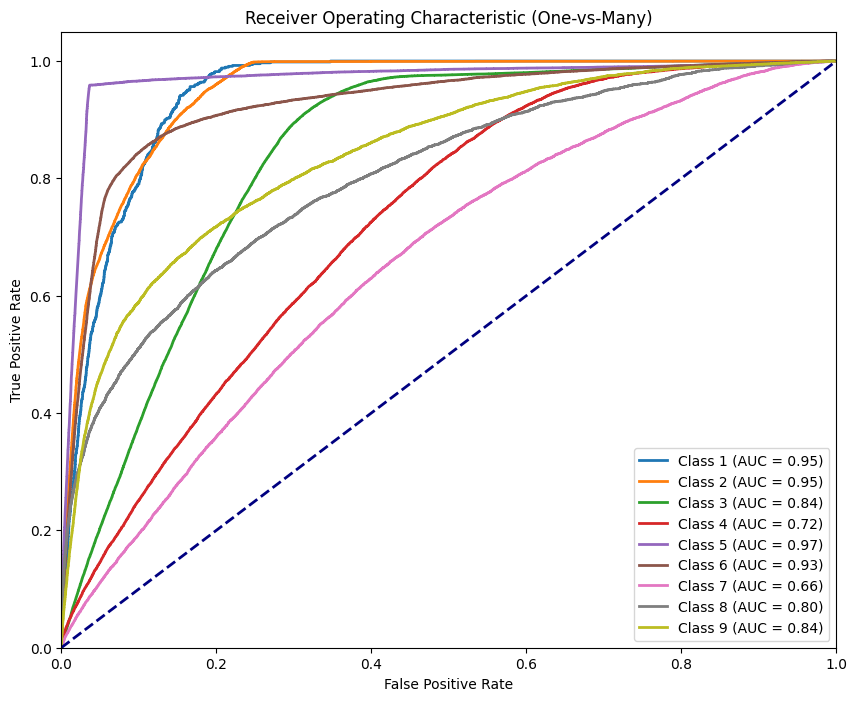

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


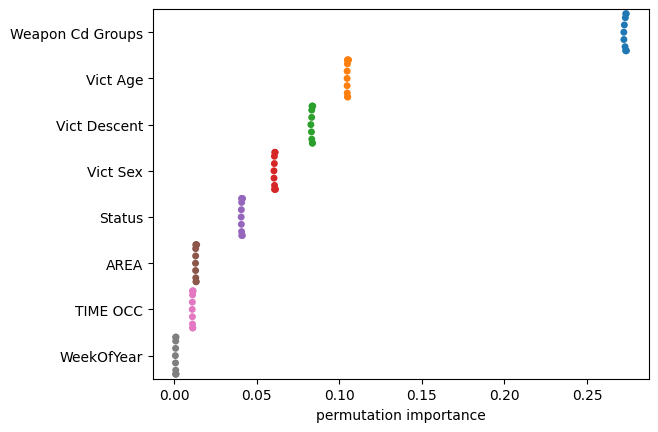

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-25 15:58:03.845727.pkl
time: 1h 32min 37s (started: 2025-04-25 15:58:03 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            # ('scale', StandardScaler()),
            # ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
            # 'AREA',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            'Status',
            'Weapon Cd Groups',
            'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.run()
    models.append(obj)

Upon adding the weapon code groups, all classes had an improved AUC by a significant margin and it became the new highest permutation importance score by a significant margin. This makes sense due to the strong ties between a use of a weapon and how severe a crime is in general sentencing. Interestingly enough the AREA (patrol district) stayed mostly unimportant along with time information throughout both of their included model iterations.

#### Fifth Model

This last iteration of the model implemented the StandardScaler method and PCA. Although it may not have much effect, there is a possibility the continuous variables may have more impact if the data is standardized and undergoes dimensionality reduction.


#########################################################################################################################################

lgbm


,cv_score
grid_id,
0,0.437609


{'cv': 0.4376085767939621, 'holdout': 0.4333558701270296}
              precision    recall  f1-score   support

           1       0.07      0.09      0.08       667
           2       0.62      0.58      0.60     13001
           3       0.54      0.80      0.65     32867
           4       0.38      0.19      0.26     16632
           5       0.78      0.94      0.85     14658
           6       0.68      0.72      0.70     18326
           7       0.26      0.09      0.13     12689
           8       0.31      0.22      0.26      4261
           9       0.40      0.35      0.37      7466

    accuracy                           0.57    120567
   macro avg       0.45      0.44      0.43    120567
weighted avg       0.53      0.57      0.53    120567



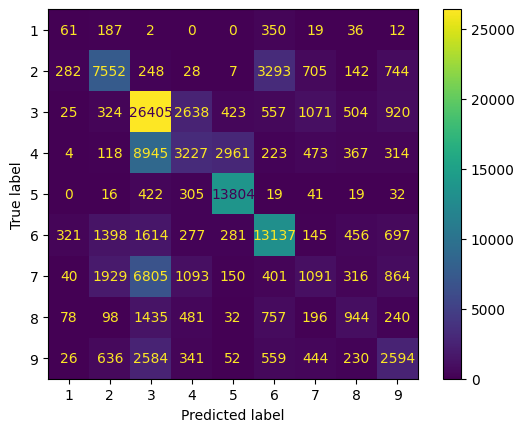

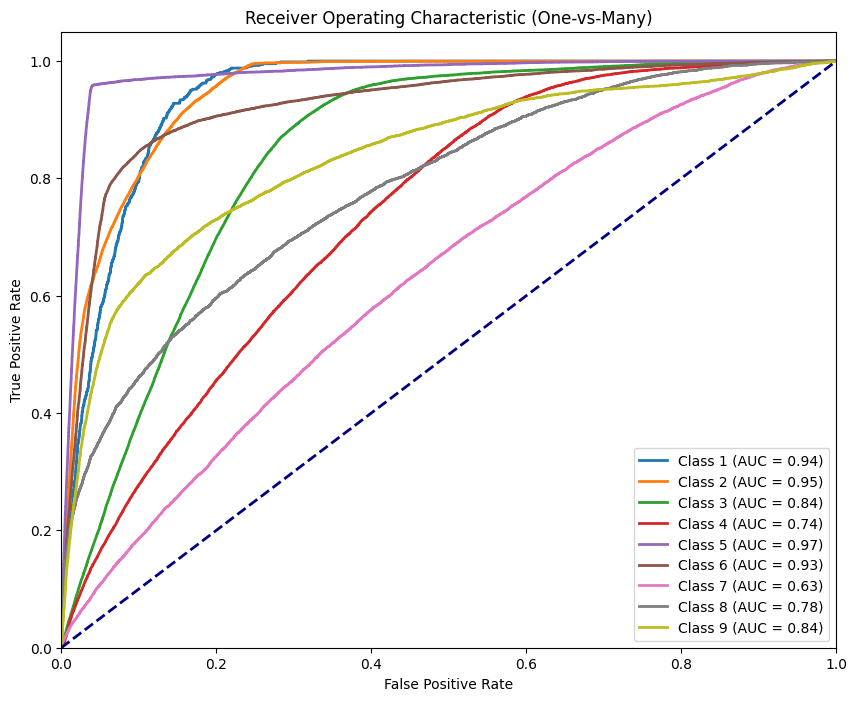

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


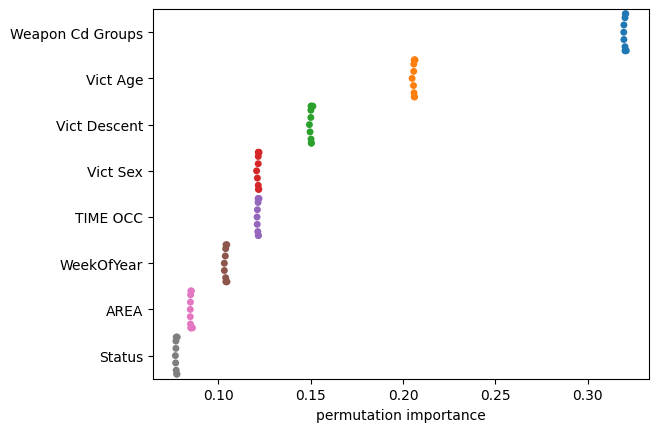

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-25 17:57:24.377068.pkl
time: 1h 3min 56s (started: 2025-04-25 17:57:24 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            ('scale', StandardScaler()),
            ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
            # 'AREA',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            'Status',
            'Weapon Cd Groups',
            'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.run()
    models.append(obj)

Standardizing the continuous data and having it undergo PCA dimensionality reduction helped to improve the permutation performance of all continuous features dramatically; however, it also reduced the overall F1 macro scores and the AUC predictions as well. In an effort to improve the model further, another model could be created that removes the Status and/or area features to see if improvement goes up. The status feature appears to have the lowest or second lowest permuation importance of the categorical variables next to area, and also presents the best candidate for removal as if we are trying to predict crime severity it makes more sense to remove the status of the case being open or leading to an arrest.

Seeking to include the status feature in a future model, improvements could be made by grouping Adult Arrest (AA) and Adult Other (AO), Juvenile Arrest (JA) and Juvenile Other (JO), and group Investigation Continued (IC) with Unkown (UNK) with unknown being the smallest group with almost no entries. This groups into categories of Adult Cases, Juvenile Cases, and Investigating; therefore, keeping most of the purpose of the original column while grouping the smaller subgroups of Adult Cases and Juvenile Cases to help against the large distribution of Investigating cases.

### Final Model Testing

The final models that were tested against the full dataset were the corrected fourth model and fifth model. These iterations of the model building process presented the most accuracy of the five developed models, and had the most promise to perform well on the full dataset. These final models included the 'WeekOfYear', 'TIME OCC', and 'Vict Age' features as quantitative variables; in addition to 'AREA', 'Status', 'Vict_Sex', 'Vict_Descent', 'Weapon Cd Groups' as continuous variables. The models using these features were also tested with and without standardizing continuous data while putting it through dimensionality reduction to see how both methods compared when pitted against the final dataset.

#### Fourth Model Analysis


#########################################################################################################################################

lgbm


,cv_score
grid_id,
0,0.448763


{'cv': 0.448762689196015, 'holdout': 0.44728618691887057}
              precision    recall  f1-score   support

           1       0.37      0.01      0.01      1129
           2       0.65      0.64      0.65     21668
           3       0.55      0.88      0.68     54768
           4       0.45      0.19      0.27     27743
           5       0.79      0.96      0.87     24394
           6       0.70      0.78      0.74     30532
           7       0.38      0.03      0.05     21135
           8       0.55      0.20      0.30      7112
           9       0.47      0.47      0.47     12464

    accuracy                           0.61    200945
   macro avg       0.55      0.46      0.45    200945
weighted avg       0.58      0.61      0.55    200945



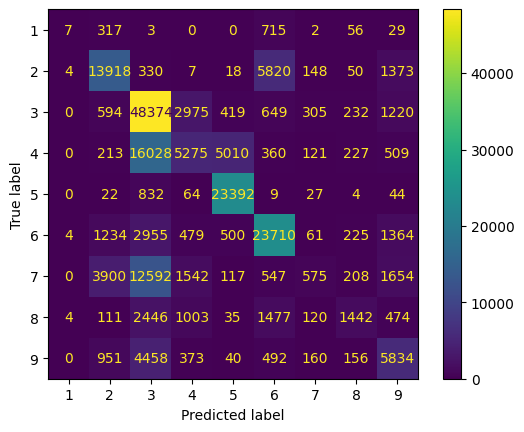

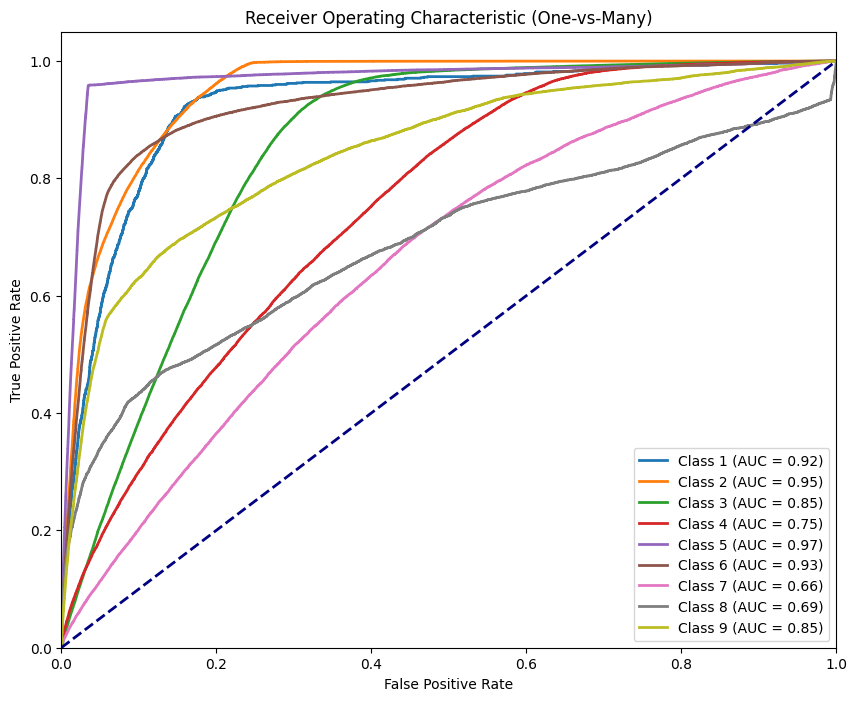

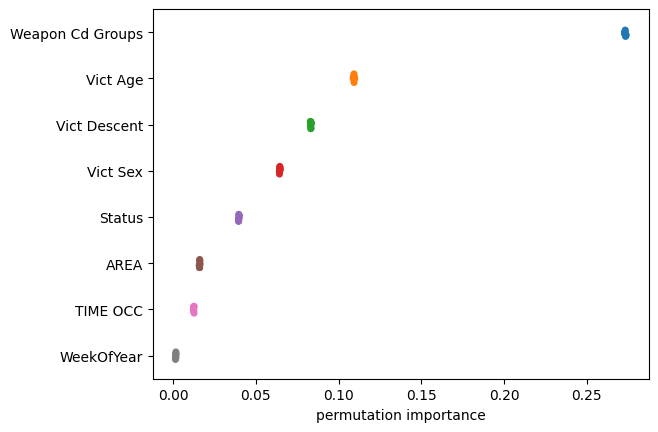

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-26 21:33:01.662743.pkl
time: 4h 22min (started: 2025-04-26 21:33:01 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            # ('scale', StandardScaler()),
            # ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
            # 'AREA',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            'Status',
            'Weapon Cd Groups',
            'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.run()
    models.append(obj)

The model above has a decent F1-macro score of about 0.45 on both the cross-validation and holdout score considering it is attempting to predict nine separate classes of data. Its correlation matrix predicts Class 3 crimes with varying accuracy, often confusing them with other crime categories. Implications as to why are illustrated in how UCR reporting is conducted, which appears to have varying amounts of theft and burglary within the 300's and 400's of the Crime Codes columns$^2$. These two categories are different in severity, and are affected by the dollar amounts stolen and whether it was only attempted theft or successful theft$^2$. Class 3 crimes are also confused with 7 as well, which include small details such as brandishing a weapon$^2$. Overall, the correlation matrix tends to confuse Class 3 crimes the most in comparison to other classes, but analysis of these mistakes indicates that the simlarity of the crimes and how intertwined they are may cause some of these confusions.

The Receiver Operating Characteristic (ROC) curve indicates surpisingly successfull one-versus-many (OVM) comparisons between classes. The ROC-OVM method was chosen as it allows a visual distinction in how well the model predicts a single class in comparison to the rest of the classes one by one. With this theory in mind, the average area under the curve (AUC) was 0.84, with classes of 7, 8 and 4 being the only classes with a AUC below 0.80. This indicates the model is great at distinguishing between classes other than 7, 8, or 4 but struggles with these classes in particular; which is further support for the previously discussed correlation matrix results with 8 being an outlier based on the matrix.

The most influential features appeared to be the three features relating to victim information being victim sex, descent, and age in ascending order; in addition to the weapon code groups feature. This makes sense, and follows an early prediction of the model possibly relying too much on the use of weapon usage to classify crimes; however, the inclusion of weapon usage in the form of categories dramtically increased model performance in a way that makes sense with crime severity.

#### Fifth Model Analysis


#########################################################################################################################################

lgbm


,cv_score
grid_id,
0,0.438005


{'cv': 0.4380045046308955, 'holdout': 0.42444679704401067}
              precision    recall  f1-score   support

           1       0.67      0.00      0.00      1129
           2       0.65      0.64      0.64     21668
           3       0.54      0.85      0.66     54768
           4       0.41      0.18      0.25     27743
           5       0.73      0.96      0.83     24394
           6       0.70      0.77      0.73     30532
           7       0.38      0.01      0.02     21135
           8       0.54      0.13      0.21      7112
           9       0.45      0.46      0.46     12464

    accuracy                           0.60    200945
   macro avg       0.56      0.45      0.42    200945
weighted avg       0.56      0.60      0.54    200945



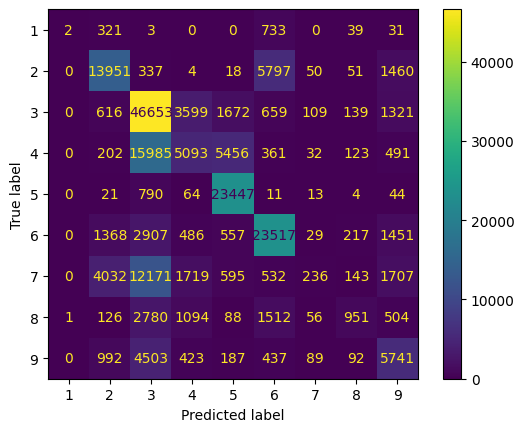

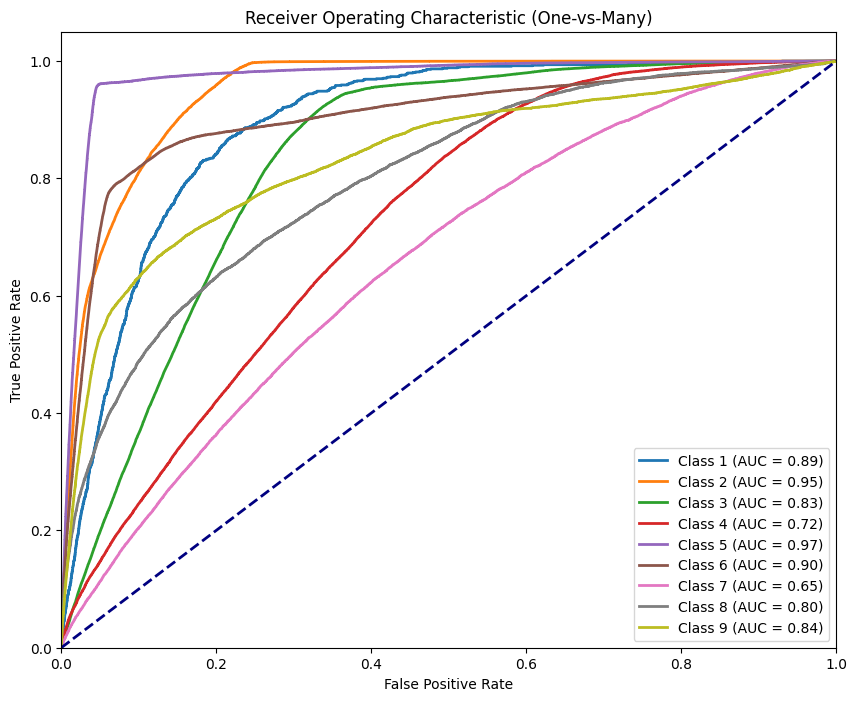

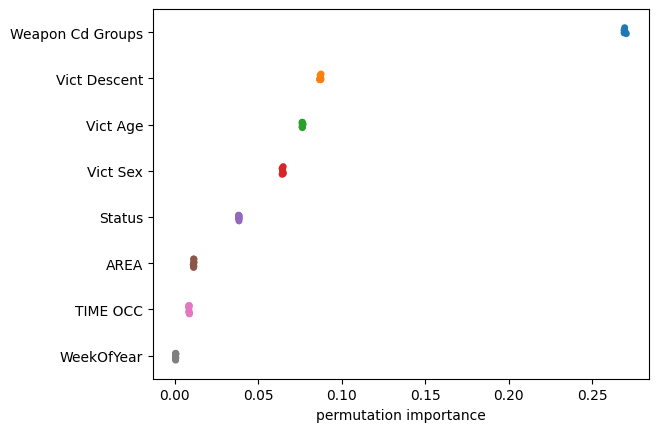

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/mays_submissions/final_project/models/2025-04-26 17:28:31.363692.pkl
time: 1h 19min 59s (started: 2025-04-26 17:28:31 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            ('scale', StandardScaler()),
            ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
            # 'AREA',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            'Status',
            'Weapon Cd Groups',
            'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.run()
    models.append(obj)

The model above has a decent but slightly poorer F1-macro score of about 0.44 during cross-validation and an F1-macro score of about 0.42 on the holdout set. The main difference in this model's composition is the rescaling of continuous variables and the use of principal component analysis (PCA) for dimensionality reduction. Implementing the rescaling and dimensionality reduction of continuous variables in a dataset typically reduces complexity of the data overall by simplifying the continuous variables into a smaller subset that retains patterns; however, the final F1-macro scores did not end up reflecting the typical trends. Where this model improved was in its ROC curve results and computational speed. The previous model iteration struggled with classes 7, 8, and 4; in comparison, this model narrows this down to only classes 7 and 4 with AUC scores below 0.80. The computation time of this model was also significantly faster, taking about a quarter of the time of its previous iteration to output results.

The correlation matrix in this iteration still predicts Class 3 crimes with varying accuracy, often confusing them with other crime categories. Class 3 crimes are still confused with class 7 crimes the most as well, which include small details such as brandishing a weapon$^2$. Overall, the correlation matrix tends to follow the previous model iteration's trends whole also losing some accuracy in exchange for improving slightly in some areas. In general, this correlation matrix for this model indicates the two models perform similarly and that despite losing overall accuracy the fifth model can pick up on and minorly adjust some of the errors of the fourth model.

The most influential features according to the permutation scores figure for the model were the same four features as before; however, the ascending order was victim sex, age, descent, and then weapon code groups for this iteration. The addition of rescaling and dimensionality reduction appeared to only level the playing field between the victim information features rather than dramatically causing the ages of victims to lose their significance within the model.

## Conclusion

#### Final Model With Subpopulation Analysis

lgbm


,cv_score
grid_id,
0,0.439900


{'cv': 0.4398998628301105, 'holdout': 0.42444679704401067}
cv: 0.440
holdout: 0.424
Vict_Sex.isin(['F','M','X']): 0.340
Vict_Descent.isin(['B','H','W']): 0.319
              precision    recall  f1-score   support

           1       0.67      0.00      0.00      1129
           2       0.65      0.64      0.64     21668
           3       0.54      0.85      0.66     54768
           4       0.41      0.18      0.25     27743
           5       0.73      0.96      0.83     24394
           6       0.70      0.77      0.73     30532
           7       0.38      0.01      0.02     21135
           8       0.54      0.13      0.21      7112
           9       0.45      0.46      0.46     12464

    accuracy                           0.60    200945
   macro avg       0.56      0.45      0.42    200945
weighted avg       0.56      0.60      0.54    200945



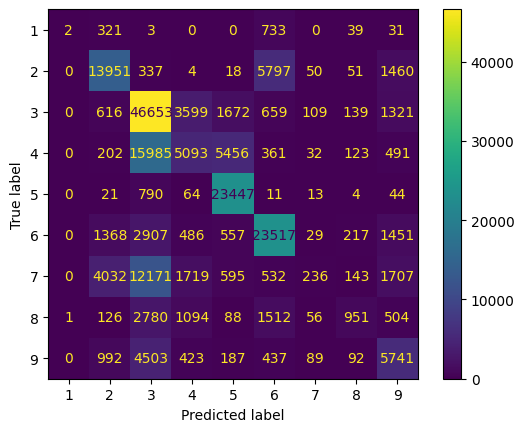

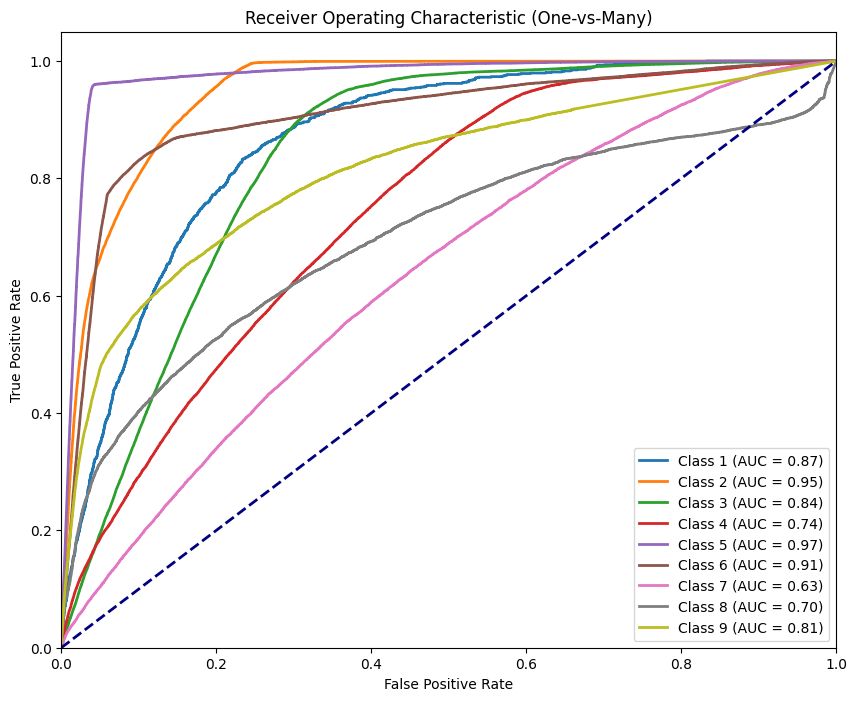

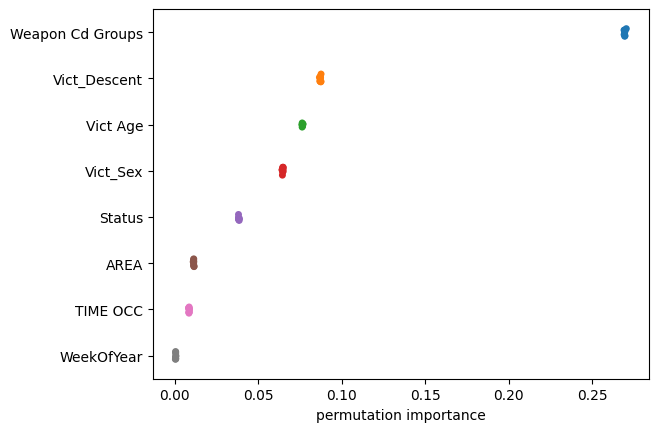

time: 1h 16min 1s (started: 2025-05-03 00:11:43 +00:00)


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wrangler = ColumnTransformer((
        ('continuous', Pipeline((
            ('impute', SimpleImputer(strategy='median', missing_values=0,)),
            ('scale', StandardScaler()),
            ('reddim', PCA()),
        )),
        (
            'Vict Age',
            'WeekOfYear',
            'TIME OCC',
            # 'AREA',
        )),

        ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False, drop='if_binary')),
        )),
        (
            'Vict_Sex',
            'Vict_Descent',
            'Status',
            'Weapon Cd Groups',
            'AREA',
        )),

    ),
    remainder='drop',
    verbose_feature_names_out=False,
)

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    # 'wrangle__continuous__n_components': np.arange(1+n_continuous_features),
    # 'learn__n_estimators': [50, 100],
    # 'learn__max_depth': [12, 15],
    # 'wrangle__continuous__impute__strategy': [(strategy='constant', missing_values=0, fill_value=int(lacrime_data['Vict Age'].mean().round()))],
}

for learner in [
    # RandomForestClassifier(random_state=seed),
   AutoML(time_budget=120, eval_method='holdout', retrain_full=False,
        task='classification', metric='macro_f1', seed=seed, verbose=0)
    ]:
    obj = lacrime(wrangler, learner, param_grid, scorer=make_scorer(f1_score, average='macro'), refit_time=600,)
    obj.train()
    obj.evaluate(subpopulations = ["Vict_Sex.isin(['F','M','X'])","Vict_Descent.isin(['B','H','W'])"])
    models.append(obj)

The final selected model was the fifth iteratation of the model implementing the rescaling and dimensionality reduction of present continuous variables. The final model included the 'WeekOfYear', 'TIME OCC', and 'Vict Age' features as quantitative variables; in addition to 'AREA', 'Status', 'Vict_Sex', 'Vict_Descent', 'Weapon Cd Groups' as continuous variables. Its ordinal variable was the grouped target variable representing the UCR crime code of a reported crime instance. The last run of the model illustrated above included additional F1-macro scores for the victim sex and victim descent categories in order to help illustrate the model's capabilities to distinguish between specific populations of individuals. For the victim sex feature the F1 score was 0.340, which indicates that the model is adequate at predicting individual victim sex between the 9 different classes of crimes present. In addition, the victim descent was not far behind with an F1 score of 0.319 for distinguishing the main three descents (being Black, Hispanic, and White) from the victim pool within the 9 different classes of crimes.

The holdout scores of each model are in the following order: 0.26, 0.26, 0.31, 0.45, and 0.42-0.44, with 0.42-44 representing the final model's generalization performances to future possible datasets. The previously mentioned scores allow for a clearer indication of how implementing details beyond just victim information, location, and days and times can dramatically improve the model performamce at identifying severe crimes. Comparisons in the below figure between the two final model candidates ROC curves revealed the same average AUC scores, but the second final model (fifth overall model) had less average variability in its scoring along with dramatically faster computation speeds.

*The below figure was captured from a Microsoft Excel Workbook where these calculations took place for ease of visual display and customization.*

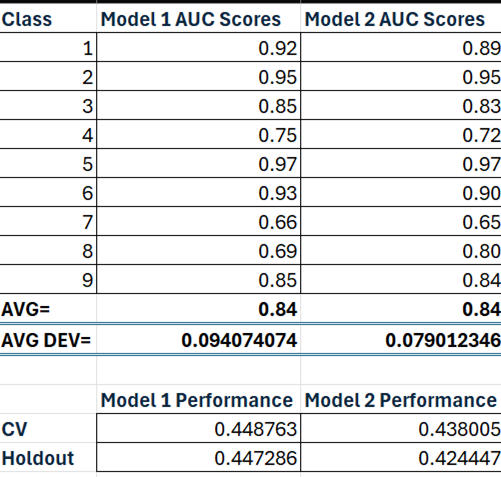

The developed model indicates that the usage and type of weapon used are one of the strongest indicators of crime severity present, with victim demographics following loosely behind. The general pitfalls of this model come from distinguishing similar crimes from their actual severity. The final model continues the trend of struggling to distinguish crimes of burglary or theft (falling into the categories 3's and 4's) along with crimes where smaller crime details fall under such as a weapon being brandished at the victim (falling into category 7). Future iterations of the developed may seek to improve its performance by implementing the unused premise codes that create more specific information about each crime and provide exact site details for each crime. Overall, the model can roughly distinguish between the different crime severities while occasionally getting tripped up on extremely similar instances of crime. These results allow for future analysis in general predictive policing methods while leaving room for new machine learning models to be developed and iterate upon the developed final model in an effort to improve overall model performance.  

## References


Dataset Location:
1. https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data

Link to UCR vs COMPSTAT Reporting PDF (located in google drive but originally obtained from the Dataset Location):
2. https://drive.google.com/file/d/1HKOWZeUbaomYyxOI0Ip-J3pbtIa6u5dW/view?usp=drive_link

Link to FBI's CJIS Division Summery Reporting System on UCR PDF (located in google drive but originally obtained linked the Dataset Location):
3. https://drive.google.com/file/d/1pc70CWiqcC_LpkW-J_5xh4i8jOEWXOgQ/view?usp=drive_link

Tasnim, S., Sarkar, P., Hossain, A., & Ali, M. A. (2019). A Classification Approach to Predict Severity of Crime on Boston City Crime Data. Data Science and SDGs: Challenges, Opportunities and Realities.
4. https://www.researchgate.net/profile/Khalek-Md-Abdul/publication/353913487_Data_Science_and_SDGs_Challenges_Opportunities_and_Realities/links/615ad42a4a82eb7cb5f5ffcd/Data-Science-and-SDGs-Challenges-Opportunities-and-Realities.pdf#page=423

Short article generalizing and explaining some predictive policing and its modern implementations:
5. https://www.brennancenter.org/our-work/research-reports/predictive-policing-explained

Sci-Kit Learn's documentation for One-vs-Rest ROC Classifier:
6. https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html

Other credits:
7. The Google Gemini AI assistant was used throughout the development of this report. Its primary use was quickly developing code to replace spaces with underscores, develop templates for creating figures throughout the dataset, and for diagnosing various errors that occurred throughout the coding processes conducted within the report.

